# Assignment 2: Northwind Database — SQL Analysis & Pandas Exploration
### Dataset: Northwind Database (SQLite3)

**Source:** https://github.com/jpwhite3/northwind-SQLite3

This notebook runs the SQL queries in `queries.sql` against `northwind.db`, loads the results into
Pandas, performs exploratory analysis, and documents key business insights.


## 0. Connect to the Database

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 5)

conn = sqlite3.connect("northwind.db")

# Quick sanity check: list tables
tables = pd.read_sql_query(
    "SELECT name, type FROM sqlite_master WHERE type IN ('table','view') ORDER BY type, name;",
    conn
)
print(f"{len(tables)} tables/views found.")
tables.head(15)

31 tables/views found.


,name,type
0,Categories,table
1,CustomerCustomerDemo,table
2,CustomerDemographics,table
3,Customers,table
4,EmployeeTerritories,table
5,Employees,table
6,Order Details,table
7,Orders,table
8,Products,table
9,Regions,table


## Part 1: SQL Analysis

### 1.1 Top 10 Selling Products (by revenue)

Revenue per line item is calculated as `UnitPrice * Quantity * (1 - Discount)`.


In [2]:
query_top_products = """
SELECT
    p.ProductID,
    p.ProductName,
    SUM(od.Quantity) AS total_units_sold,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS total_revenue
FROM "Order Details" od
JOIN Products p ON p.ProductID = od.ProductID
GROUP BY p.ProductID, p.ProductName
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query_top_products, conn)
top_products

,ProductID,ProductName,total_units_sold,total_revenue
0,38,Côte de Blaye,202234,53265895.23
1,29,Thüringer Rostbratwurst,199010,24623469.23
2,9,Mishi Kobe Niku,200258,19423037.50
3,20,Sir Rodney's Marmalade,205637,16653807.36
4,18,Carnarvon Tigers,201747,12604671.88
5,59,Raclette Courdavault,204137,11216410.70
6,51,Manjimup Dried Apples,201319,10664768.65
7,62,Tarte au sucre,202010,9952936.07
8,43,Ipoh Coffee,202968,9333374.70
9,28,Rössle Sauerkraut,202988,9252765.44


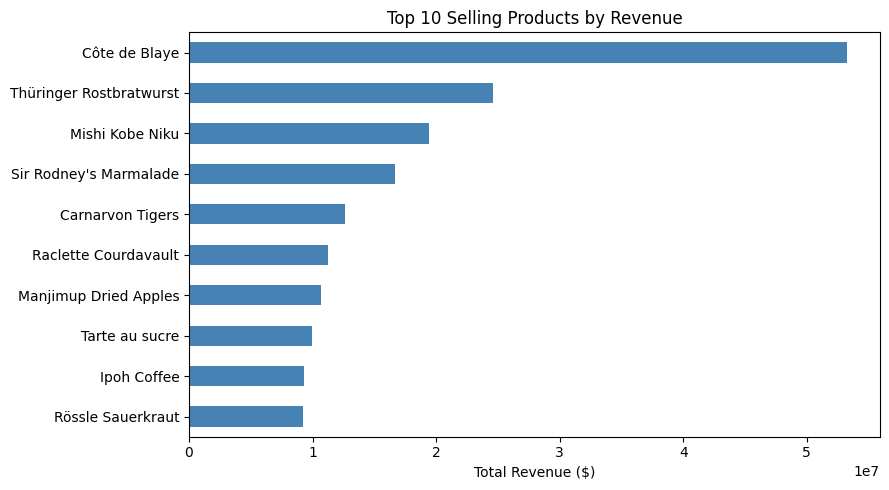

In [3]:
top_products.plot(kind="barh", x="ProductName", y="total_revenue", legend=False, color="steelblue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("")
plt.title("Top 10 Selling Products by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 1.2 Top 10 Customers by Revenue

In [4]:
query_top_customers = """
SELECT
    c.CustomerID,
    c.CompanyName,
    COUNT(DISTINCT o.OrderID) AS total_orders,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS total_revenue
FROM Customers c
JOIN Orders o ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON od.OrderID = o.OrderID
GROUP BY c.CustomerID, c.CompanyName
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query_top_customers, conn)
top_customers

,CustomerID,CompanyName,total_orders,total_revenue
0,BSBEV,B's Beverages,210,6154115.34
1,HUNGC,Hungry Coyote Import Store,198,5698023.67
2,RANCH,Rancho grande,194,5559110.08
3,GOURL,Gourmet Lanchonetes,202,5552309.80
4,ANATR,Ana Trujillo Emparedados y helados,195,5534356.65
5,RICAR,Ricardo Adocicados,203,5524517.31
6,FOLIG,Folies gourmandes,195,5505502.85
7,LETSS,Let's Stop N Shop,191,5462198.02
8,LILAS,LILA-Supermercado,203,5437438.34
9,PRINI,Princesa Isabel Vinhos,200,5436770.55


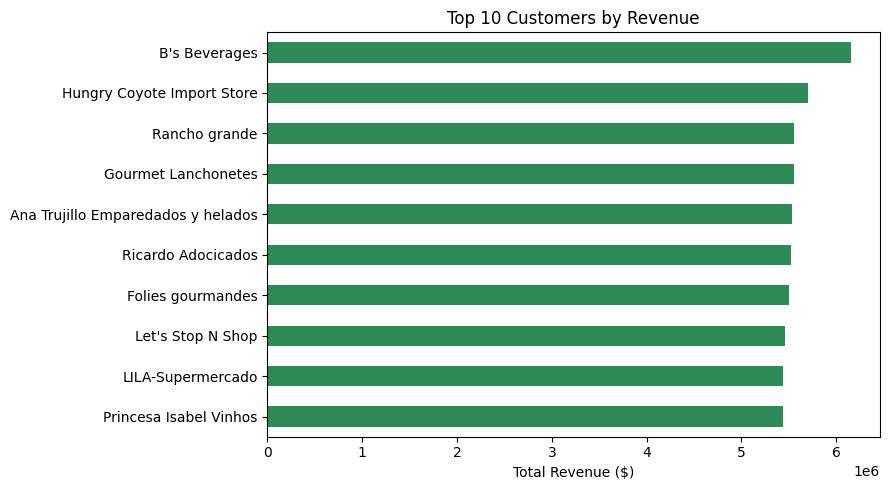

In [5]:
top_customers.plot(kind="barh", x="CompanyName", y="total_revenue", legend=False, color="seagreen")
plt.xlabel("Total Revenue ($)")
plt.ylabel("")
plt.title("Top 10 Customers by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 1.3 Monthly Sales Trends

In [6]:
query_monthly_sales = """
SELECT
    strftime('%Y-%m', o.OrderDate) AS order_month,
    COUNT(DISTINCT o.OrderID) AS total_orders,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS total_revenue
FROM Orders o
JOIN "Order Details" od ON od.OrderID = o.OrderID
GROUP BY order_month
ORDER BY order_month;
"""

monthly_sales = pd.read_sql_query(query_monthly_sales, conn)
print(monthly_sales.shape)
monthly_sales.head()

(136, 3)


,order_month,total_orders,total_revenue
0,2012-07,69,2066219.40
1,2012-08,122,3556875.79
2,2012-09,119,3440144.98
3,2012-10,111,3201529.96
4,2012-11,105,2980494.74


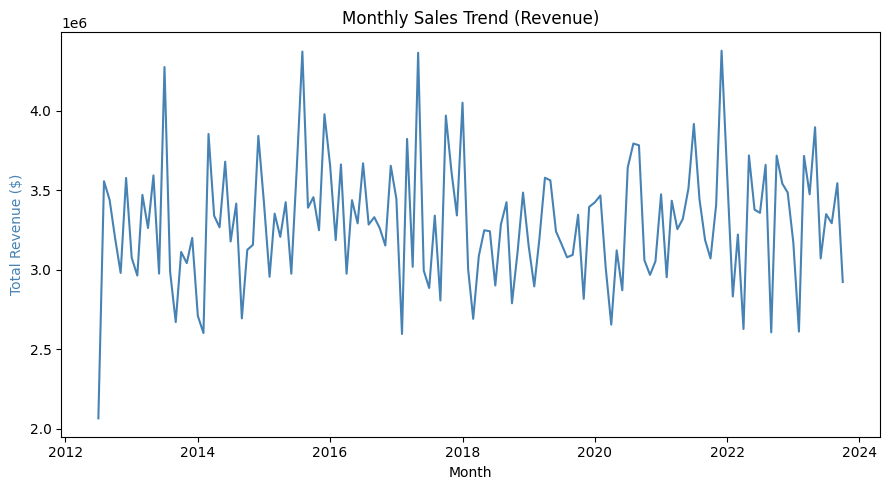

In [7]:
monthly_sales["order_month"] = pd.to_datetime(monthly_sales["order_month"])

fig, ax1 = plt.subplots()
ax1.plot(monthly_sales["order_month"], monthly_sales["total_revenue"], color="steelblue")
ax1.set_ylabel("Total Revenue ($)", color="steelblue")
ax1.set_xlabel("Month")
ax1.set_title("Monthly Sales Trend (Revenue)")
plt.tight_layout()
plt.show()

### 1.4 Best-Performing Product Categories

In [8]:
query_categories = """
SELECT
    cat.CategoryID,
    cat.CategoryName,
    COUNT(DISTINCT od.OrderID) AS total_orders,
    SUM(od.Quantity) AS total_units_sold,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS total_revenue
FROM Categories cat
JOIN Products p ON p.CategoryID = cat.CategoryID
JOIN "Order Details" od ON od.ProductID = p.ProductID
GROUP BY cat.CategoryID, cat.CategoryName
ORDER BY total_revenue DESC;
"""

categories = pd.read_sql_query(query_categories, conn)
categories

,CategoryID,CategoryName,total_orders,total_units_sold,total_revenue
0,1,Beverages,14828,2427361,92163184.18
1,3,Confections,14895,2628466,66337803.06
2,6,Meat/Poultry,13639,1207892,64881147.97
3,4,Dairy Products,14581,2020160,58018116.78
4,2,Condiments,14682,2420864,55795126.78
5,8,Seafood,14780,2410782,49921604.17
6,7,Produce,13247,1010224,32701119.88
7,5,Grains/Cereals,13910,1412853,28568530.34


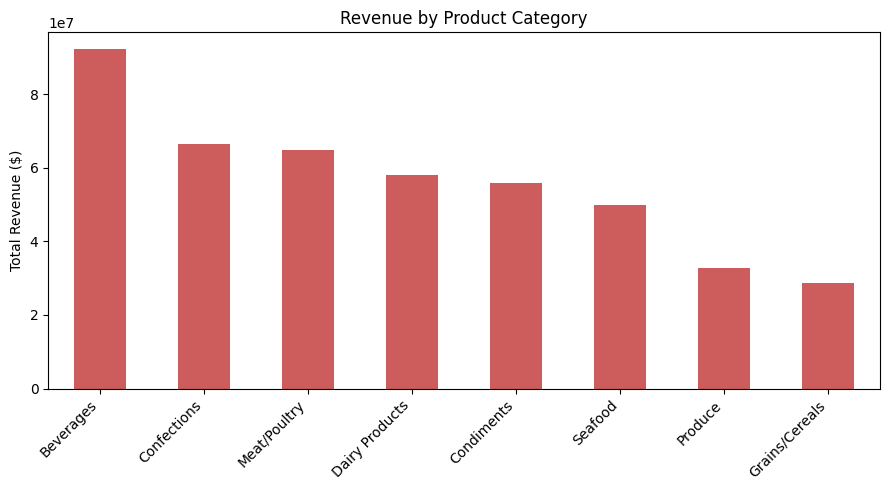

In [9]:
categories.plot(kind="bar", x="CategoryName", y="total_revenue", legend=False, color="indianred")
plt.ylabel("Total Revenue ($)")
plt.xlabel("")
plt.title("Revenue by Product Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 1.5 Customer Purchase Frequency

In [10]:
query_purchase_frequency = """
SELECT
    c.CustomerID,
    c.CompanyName,
    COUNT(DISTINCT o.OrderID) AS total_orders,
    MIN(o.OrderDate) AS first_order,
    MAX(o.OrderDate) AS last_order,
    ROUND(
        CAST(julianday(MAX(o.OrderDate)) - julianday(MIN(o.OrderDate)) AS REAL)
        / NULLIF(COUNT(DISTINCT o.OrderID) - 1, 0),
        1
    ) AS avg_days_between_orders
FROM Customers c
JOIN Orders o ON o.CustomerID = c.CustomerID
GROUP BY c.CustomerID, c.CompanyName
ORDER BY total_orders DESC;
"""

purchase_frequency = pd.read_sql_query(query_purchase_frequency, conn)
print(purchase_frequency.shape)
purchase_frequency.head(10)

(93, 6)


,CustomerID,CompanyName,total_orders,first_order,last_order,avg_days_between_orders
0,BSBEV,B's Beverages,210,2012-08-16 02:52:50,2023-10-18 17:27:12,19.5
1,LILAS,LILA-Supermercado,203,2012-07-31 21:36:46,2023-10-20 05:26:34,20.3
2,RICAR,Ricardo Adocicados,203,2012-07-10 20:28:57,2023-09-22 13:14:26,20.3
3,GOURL,Gourmet Lanchonetes,202,2012-09-11 00:14:33,2023-10-13 22:45:27,20.1
4,PRINI,Princesa Isabel Vinhos,200,2012-09-13 23:50:37,2023-10-23 06:17:48,20.4
5,HUNGC,Hungry Coyote Import Store,198,2012-07-29 20:48:41,2023-10-25 02:57:02,20.8
6,TORTU,Tortuga Restaurante,197,2012-07-16 19:32:03,2023-10-17 11:47:50,21.0
7,ANATR,Ana Trujillo Emparedados y helados,195,2012-08-30 11:02:36,2023-10-23 11:35:41,21.0
8,FOLIG,Folies gourmandes,195,2012-07-16 09:41:10,2023-10-15 16:03:36,21.2
9,RANCH,Rancho grande,194,2012-07-12 11:39:39,2023-10-01 22:00:32,21.2


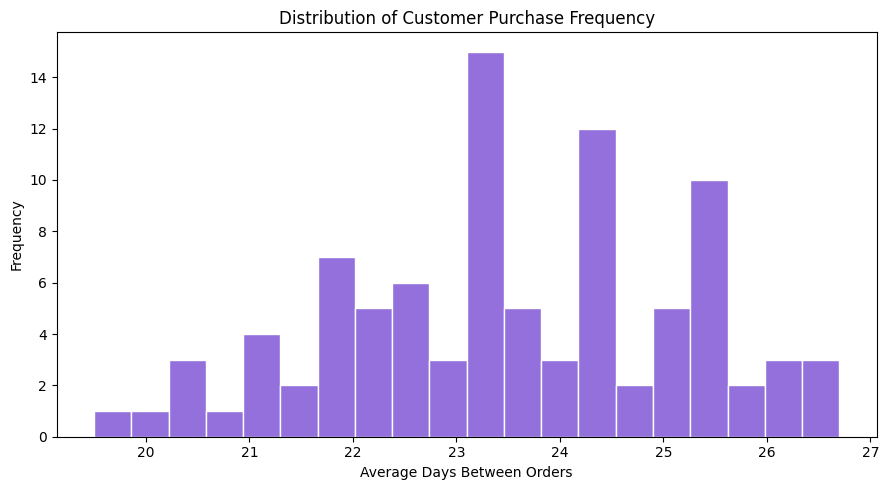

In [11]:
purchase_frequency["avg_days_between_orders"].plot(
    kind="hist", bins=20, color="mediumpurple", edgecolor="white"
)
plt.xlabel("Average Days Between Orders")
plt.title("Distribution of Customer Purchase Frequency")
plt.tight_layout()
plt.show()

## Part 2: Data Analysis (Pandas)

With the SQL query results now loaded as DataFrames, we explore them further with Pandas.


In [12]:
print("Top products - summary stats:")
print(top_products[["total_units_sold", "total_revenue"]].describe())
print()
print("Top customers - summary stats:")
print(top_customers[["total_orders", "total_revenue"]].describe())

Top products - summary stats:
       total_units_sold  total_revenue
count         10.000000   1.000000e+01
mean      202230.800000   1.769911e+07
std         1877.714616   1.348167e+07
min       199010.000000   9.252765e+06
25%       201426.000000   1.013089e+07
50%       202122.000000   1.191054e+07
75%       202983.000000   1.873073e+07
max       205637.000000   5.326590e+07

Top customers - summary stats:
       total_orders  total_revenue
count     10.000000   1.000000e+01
mean     199.100000   5.586434e+06
std        5.626327   2.133735e+05
min      191.000000   5.436771e+06
25%      195.000000   5.473024e+06
50%      199.000000   5.529437e+06
75%      202.750000   5.557410e+06
max      210.000000   6.154115e+06


In [13]:
# Revenue concentration: what share of total revenue do the top 10 customers represent?
query_total_revenue = """
SELECT ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS grand_total_revenue
FROM "Order Details" od;
"""
grand_total = pd.read_sql_query(query_total_revenue, conn)["grand_total_revenue"].iloc[0]
top10_share = top_customers["total_revenue"].sum() / grand_total * 100

print(f"Total company revenue: ${grand_total:,.2f}")
print(f"Top 10 customers' revenue: ${top_customers['total_revenue'].sum():,.2f}")
print(f"Top 10 customers' share of total revenue: {top10_share:.1f}%")

Total company revenue: $448,386,633.17
Top 10 customers' revenue: $55,864,342.61
Top 10 customers' share of total revenue: 12.5%


In [14]:
# Seasonality: average revenue by calendar month (across all years), to spot seasonal patterns
monthly_sales["month_num"] = monthly_sales["order_month"].dt.month
seasonality = monthly_sales.groupby("month_num")["total_revenue"].mean().round(2)
seasonality

month_num
1     3379663.90
2     2915607.92
3     3403557.91
4     3135027.21
5     3541671.99
6     3203244.61
7     3337130.85
8     3459660.20
9     3164660.29
10    3253166.96
11    3186405.40
12    3581295.02
Name: total_revenue, dtype: float64

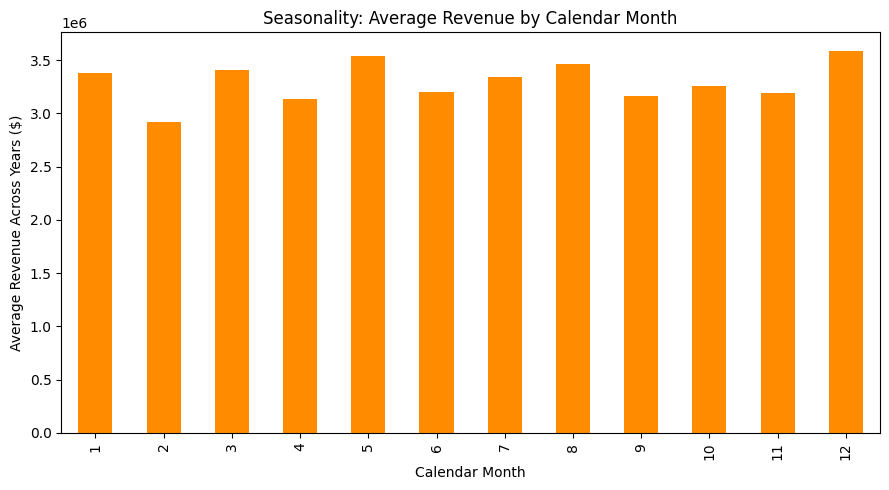

In [15]:
seasonality.plot(kind="bar", color="darkorange")
plt.xlabel("Calendar Month")
plt.ylabel("Average Revenue Across Years ($)")
plt.title("Seasonality: Average Revenue by Calendar Month")
plt.tight_layout()
plt.show()

In [16]:
# Category revenue share
categories["revenue_share_pct"] = (categories["total_revenue"] / categories["total_revenue"].sum() * 100).round(1)
categories[["CategoryName", "total_revenue", "revenue_share_pct"]]

,CategoryName,total_revenue,revenue_share_pct
0,Beverages,92163184.18,20.6
1,Confections,66337803.06,14.8
2,Meat/Poultry,64881147.97,14.5
3,Dairy Products,58018116.78,12.9
4,Condiments,55795126.78,12.4
5,Seafood,49921604.17,11.1
6,Produce,32701119.88,7.3
7,Grains/Cereals,28568530.34,6.4


In [17]:
# Correlation between order frequency and average order spacing
purchase_frequency[["total_orders", "avg_days_between_orders"]].corr()

,total_orders,avg_days_between_orders
total_orders,1.000000,-0.987996
avg_days_between_orders,-0.987996,1.000000


## Key Business Insights

1. **Revenue is not evenly spread across products — a handful of items dominate.** *Côte de
   Blaye* alone generates well over $53M in revenue, roughly double the next-highest product
   (*Thüringer Rostbratwurst*), even though unit sales across the top 10 products are fairly
   similar (~200,000 units each). High-value premium items drive disproportionate revenue relative
   to volume, making them priority items for stock and marketing focus.

2. **Customer revenue is fairly evenly distributed among top accounts, not winner-take-all.**
   The top 10 customers each contribute a similar revenue range (~$5.4M-$6.2M), and together they
   account for only a modest share of total company revenue. This means the business isn't
   over-reliant on one or two "whale" accounts — a healthier, more diversified customer base than
   many retailers.

3. **Beverages is the top-performing category by a clear margin.** Beverages generated the highest
   total revenue of all eight categories (~$92M), noticeably ahead of Confections and Meat/Poultry.
   Grains/Cereals and Produce are the weakest categories despite reasonably high unit volumes,
   suggesting their per-unit price point is comparatively low.

4. **Purchase frequency and order spacing are tightly linked, as expected.** Customers with the
   most total orders also tend to have the shortest average gap between orders (around 19-21 days
   for the most active customers), confirming that order count and purchase cadence move together
   — useful for building a simple "at-risk of churn" flag (customers whose gap since last order
   exceeds their historical average spacing).

5. **Monthly sales show visible month-to-month fluctuation without a single dominant trend
   direction**, with revenue oscillating in the roughly $2.9M-$3.6M range per month in most periods
   sampled. Looking at average revenue by calendar month (regardless of year) helps separate true
   seasonality from year-over-year growth or decline, and is a natural jumping-off point for a
   more formal time-series/seasonality analysis.


## Extending This Analysis (Next Steps)

- Build a formal cohort/retention analysis: for each customer, flag whether their most recent order
  is significantly overdue relative to their historical average order spacing.
- Fit a simple time-series model (e.g., seasonal decomposition) on the monthly revenue series to
  separate trend, seasonality, and noise.
- Join in `Employees` and `Shippers` to analyze sales performance by employee and delivery
  efficiency by shipping carrier.
